# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [26]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [27]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

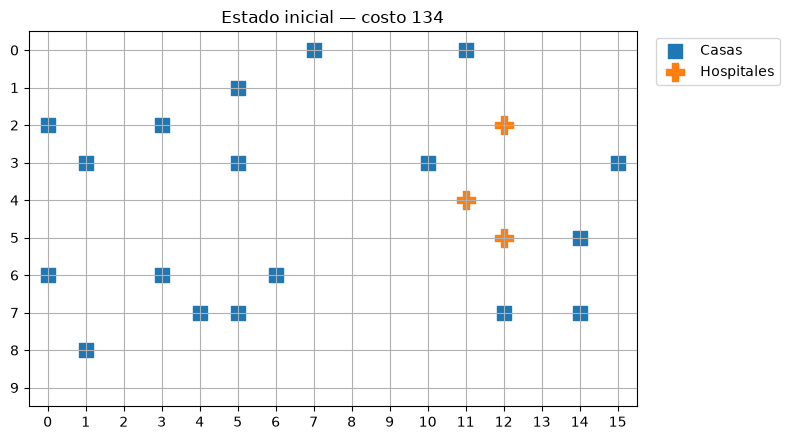

In [28]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [29]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 134
Costo final: 62
Iteraciones con mejora: 13


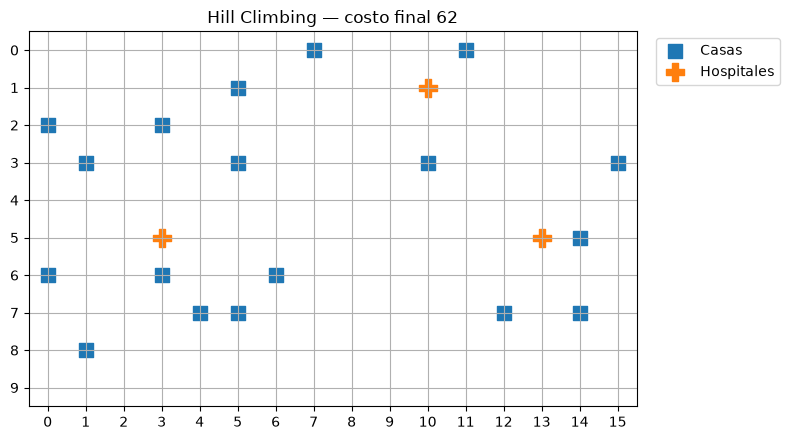

In [30]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [total_cost(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing — costo final {history[-1]}')

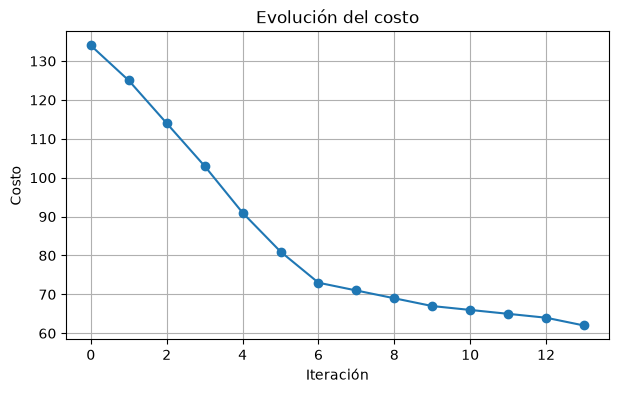

In [31]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 56
Reinicio ganador: 2


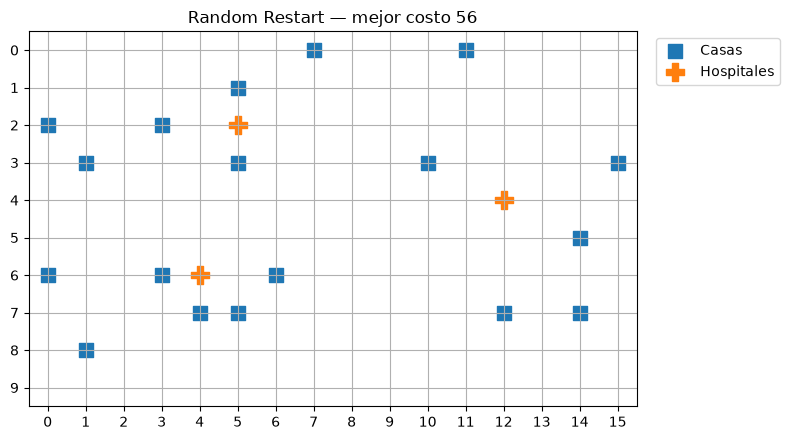

In [32]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart — mejor costo {best["final_cost"]}')

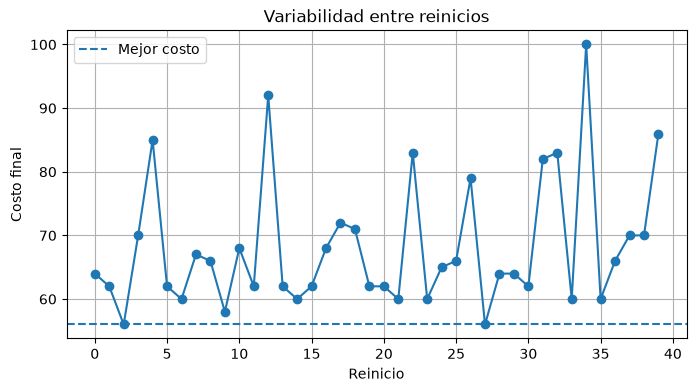

In [33]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4))
plt.plot(final_costs, marker='o')
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show()

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

In [34]:
def euclidean(a, b):
    return np.sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2)


def total_cost_euclidean(houses, hospitals):
    return sum(min(euclidean(house, hospital) for hospital in hospitals)
               for house in houses)

### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

In [35]:
results = []
for k in range(1, 6):
    best_k, _ = random_restart(HEIGHT, WIDTH, houses, k, restarts=40, seed=SEED)
    results.append((k, best_k['final_cost']))

results

[(1, 114), (2, 76), (3, 56), (4, 46), (5, 38)]

Agregar hospitales no siempre produce la misma reducción en el costo. Según lo visto en la muestra tomada, la reducción va disminuyendo a medida que se agregan hospitales. Por ejemplo se ve una reducción de 38 al pasar de 1 a 2 hospitales, pero solo una reducción de 8 al pasar de 4 a 5 hospitales. Lo cual hace probable que llegue un punto en el que agregar hospitales no produzca una reducción significativa en el costo, dependiendo también de la distribución de las casas, que en este caso está siendo controlada por la semilla.

### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados?

In [38]:
def neighbors_of_state_two_moves(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1), (-2, 0), (2, 0), (0, -2), (0, 2)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state_two_moves(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 22
Costo actual: 134
Mejor costo vecino: 114


Hay un aumento de 10 en el numero de vecinos evaluados (de 12 a 22), el cual es un aumento normal debido a que se duplicaron la cantidad de posiciones que se evaluan para cada hospital. Sin embargo, se detiene en el mismo punto que el vecindario de una celda, lo cual es la limitación de Hill Climbing, que es que puede quedarse atrapado en óptimos locales. A pesar de eso, el mejor costo de vecino sí mejora dentro de las nuevas opciones de movimiento (de 125 a 114), lo cual indica que el vecindario de dos celdas es mejor que el de una celda, pero no es suficiente para escapar del óptimo local en el que se encuentra.

## Preguntas de cierre

1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?
2. ¿El resultado depende del estado inicial?
3. ¿Random Restart garantiza encontrar el óptimo global?
4. ¿Qué información se pierde al conservar únicamente el mejor vecino?

### 1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?
Hill Climbing no necesita construir todo el espacio de búsqueda porque es un algoritmo de búsqueda local, por tanto, solo necesita conocer el estado actual y sus vecinos inmediatos para decidir cuál será el siguiente movimiento. Esto puede ser beneficioso en problemas con espacios de búsqueda grandes, ya que evita la necesidad de almacenar o explorar todos los posibles estados. Teniendo como limitación que puede quedarse atrapado en óptimos locales, mesetas o valles.

### 2. ¿El resultado depende del estado inicial?
Sí. El resultado de Hill Climbing depende del estado inicial, porque diferentes estados iniciales pueden llevar a óptimos locales diferentes. Por eso, ejecutar el algoritmo varias veces con distintos estados iniciales puede producir soluciones diferentes, así como se realizó en la actividad de Random Restart.

### 3. ¿Random Restart garantiza encontrar el óptimo global?
No, Random Restart no garantiza encontrar el óptimo global. Aunque aumenta la probabilidad de encontrar una solución mejor, no asegura que se encuentre el óptimo global del problema.

### 4. ¿Qué información se pierde al conservar únicamente el mejor vecino?
Se pierde información sobre las demás alternativas del vecindario. Al conservar solo el mejor vecino, Hill Climbing descarta caminos que podrían conducir posteriormente a una solución globalmente mejor.